In [2]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [3]:
import os

# Going one more level deeper into sinhala_dataset
BASE = "/kaggle/input/datasets/dgvdeelaka/sinhala-letters-dataset/sinhala_dataset"

print("What is inside  sinhala_dataset/:")
print("─" * 50)

items = sorted(os.listdir(BASE))
print(f"Total items found: {len(items)}")
print(f"\nFirst 15 items:")
for item in items[:15]:
    full_path = os.path.join(BASE, item)
    kind = "FOLDER" if os.path.isdir(full_path) else "FILE"
    count = len(os.listdir(full_path)) if os.path.isdir(full_path) else ""
    print(f"  {kind}  →  {item}   {f'({count} images)' if count else ''}")

print(f"\nLast 15 items:")
for item in items[-15:]:
    full_path = os.path.join(BASE, item)
    kind = "FOLDER" if os.path.isdir(full_path) else "FILE"
    count = len(os.listdir(full_path)) if os.path.isdir(full_path) else ""
    print(f"  {kind}  →  {item}   {f'({count} images)' if count else ''}")


What is inside  sinhala_dataset/:
──────────────────────────────────────────────────
Total items found: 454

First 15 items:
  FOLDER  →  187   (155 images)
  FOLDER  →  393   (192 images)
  FOLDER  →  394   (192 images)
  FOLDER  →  400   (192 images)
  FOLDER  →  406   (192 images)
  FOLDER  →  409   (192 images)
  FOLDER  →  414   (192 images)
  FOLDER  →  415   (192 images)
  FOLDER  →  416   (192 images)
  FOLDER  →  417   (192 images)
  FOLDER  →  418   (192 images)
  FOLDER  →  419   (192 images)
  FOLDER  →  420   (192 images)
  FOLDER  →  421   (192 images)
  FOLDER  →  422   (192 images)

Last 15 items:
  FOLDER  →  ෆ්‍ර   (192 images)
  FOLDER  →  ෆ්‍රැ   (192 images)
  FOLDER  →  ෆ්‍රෑ   (192 images)
  FOLDER  →  ෆ්‍රි   (192 images)
  FOLDER  →  ෆ්‍රී   (192 images)
  FOLDER  →  ෆා   (192 images)
  FOLDER  →  ෆැ   (192 images)
  FOLDER  →  ෆෑ   (192 images)
  FOLDER  →  ෆි   (192 images)
  FOLDER  →  ෆී   (192 images)
  FOLDER  →  ෆු   (192 images)
  FOLDER  →  ෆූ   (192 i

In [4]:
#check GPU active
import tensorflow as tf

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"GPU devices        : {tf.config.list_physical_devices('GPU')}")



2026-03-27 12:52:18.282372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774615938.520193      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774615938.585665      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774615939.110021      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774615939.110056      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774615939.110059      55 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU available      : True
GPU devices        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
import os
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [8]:
# Use the DATASET_PATH you confirmed in Cell 2
DATASET_PATH="/kaggle/input/datasets/dgvdeelaka/sinhala-letters-dataset/sinhala_dataset"
class_folders = sorted(os.listdir(DATASET_PATH))
NUM_CLASSES   = len(class_folders)

print(f" Total Sinhala character classes : {NUM_CLASSES}")
print("─" * 50)

class_counts = {}
total = 0

for letter in class_folders:
    folder_path = os.path.join(DATASET_PATH, letter)
    
    # Count only image files
    images = [f for f in os.listdir(folder_path)
               if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    count = len(images)
    class_counts[letter] = count
    total += count

print(f"Total images in dataset : {total:,}")
print(f"Min images in a class   : {min(class_counts.values())}")
print(f"Max images in a class   : {max(class_counts.values())}")
print(f"Average per class       : {total / NUM_CLASSES:.1f}")

# Warn about classes with very few images
low = {k: v for k, v in class_counts.items() if v < 15}
if low:
    print(f"\n Classes with fewer than 15 images:")
    for letter, count in low.items():
        print(f"   '{letter}'  →  {count} images")
else:
    print(f"\n All classes have 15+ images — good!")

 Total Sinhala character classes : 454
──────────────────────────────────────────────────
Total images in dataset : 87,141
Min images in a class   : 155
Max images in a class   : 199
Average per class       : 191.9

 All classes have 15+ images — good!


In [9]:
import json

# index → Sinhala letter
label_map = {str(idx): letter
             for idx, letter in enumerate(class_folders)}

# Save to working directory (you will download this later)
os.makedirs("/kaggle/working/models", exist_ok=True)

with open("/kaggle/working/models/label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

print(f"label_map.json saved → /kaggle/working/models/label_map.json")
print(f"\n   Sample entries:")
for k, v in list(label_map.items())[:10]:
    print(f"   [{k}]  →  '{v}'")

label_map.json saved → /kaggle/working/models/label_map.json

   Sample entries:
   [0]  →  '187'
   [1]  →  '393'
   [2]  →  '394'
   [3]  →  '400'
   [4]  →  '406'
   [5]  →  '409'
   [6]  →  '414'
   [7]  →  '415'
   [8]  →  '416'
   [9]  →  '417'


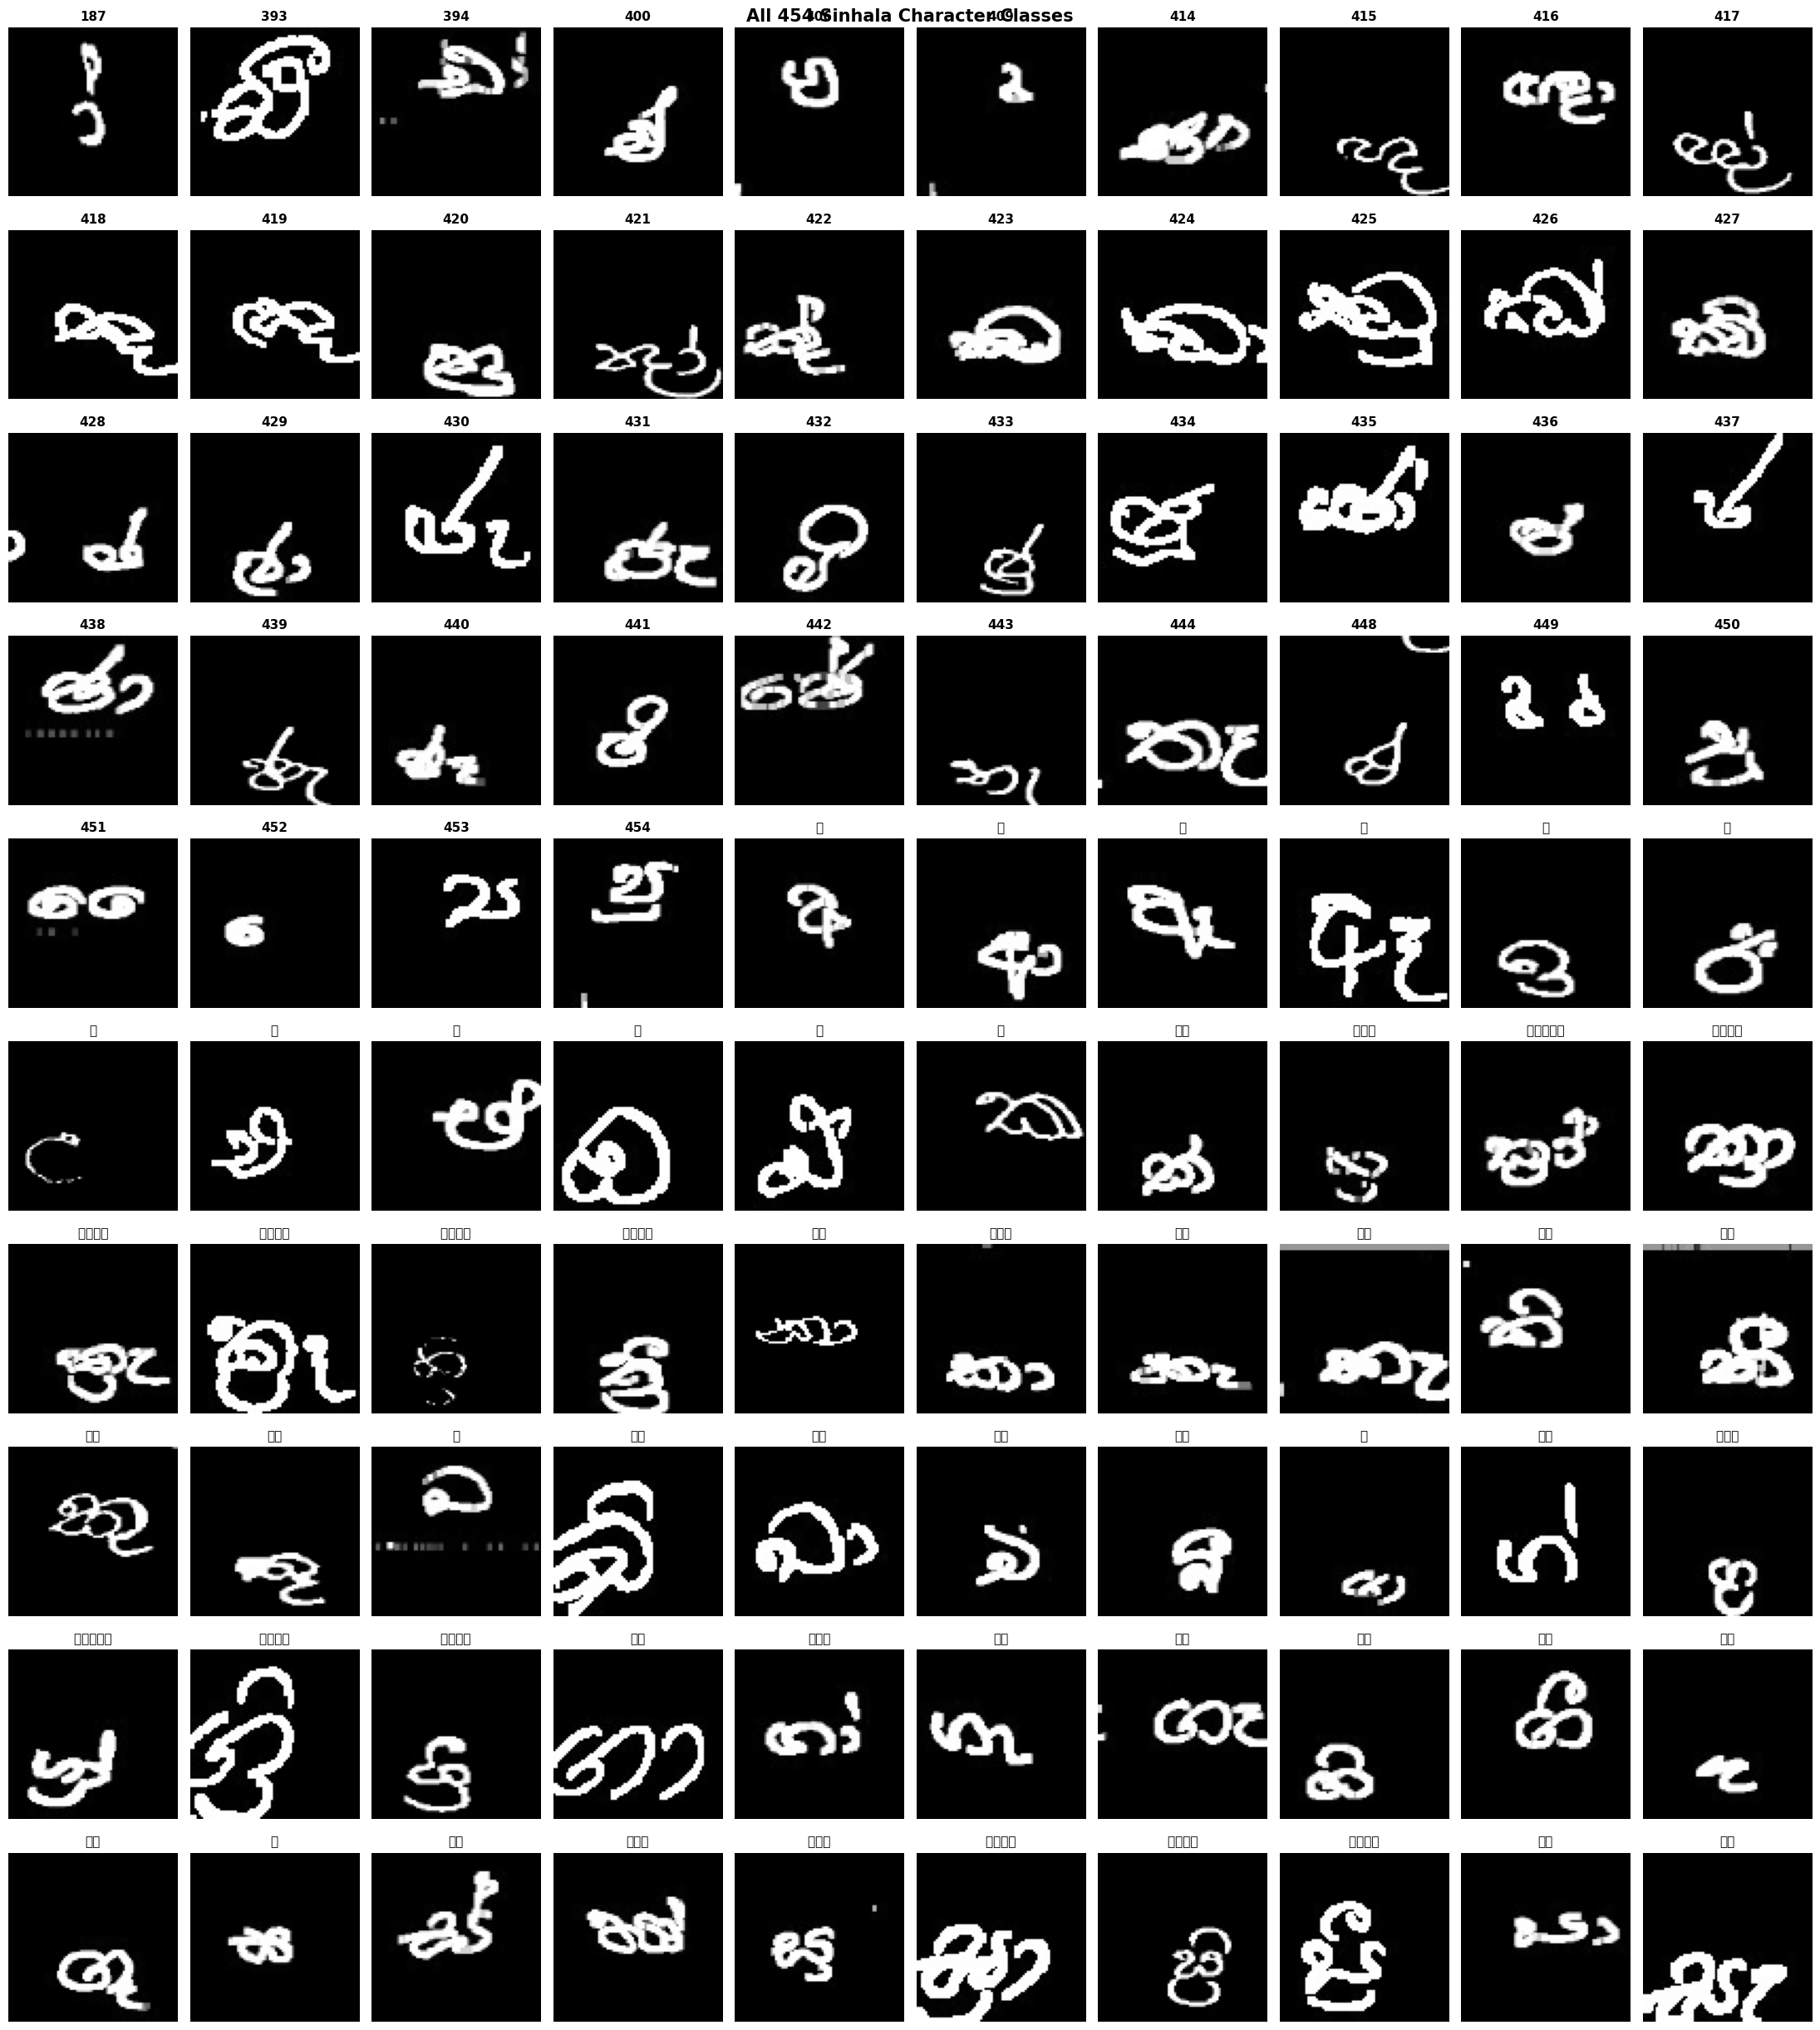

Chart saved


In [10]:
cols = 10
rows = min(10, (NUM_CLASSES + cols - 1) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 2.5))
axes = axes.flatten()

for idx, letter in enumerate(class_folders):
    if idx >= len(axes):
        break
    folder_path = os.path.join(DATASET_PATH, letter)
    img_files   = os.listdir(folder_path)
    if not img_files:
        continue
    img_path = os.path.join(folder_path, img_files[0])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(letter, fontsize=11, fontweight='bold')
    axes[idx].axis('off')

for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.suptitle(f"All {NUM_CLASSES} Sinhala Character Classes",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/all_classes.png", dpi=100, bbox_inches='tight')
plt.show()
print("Chart saved")

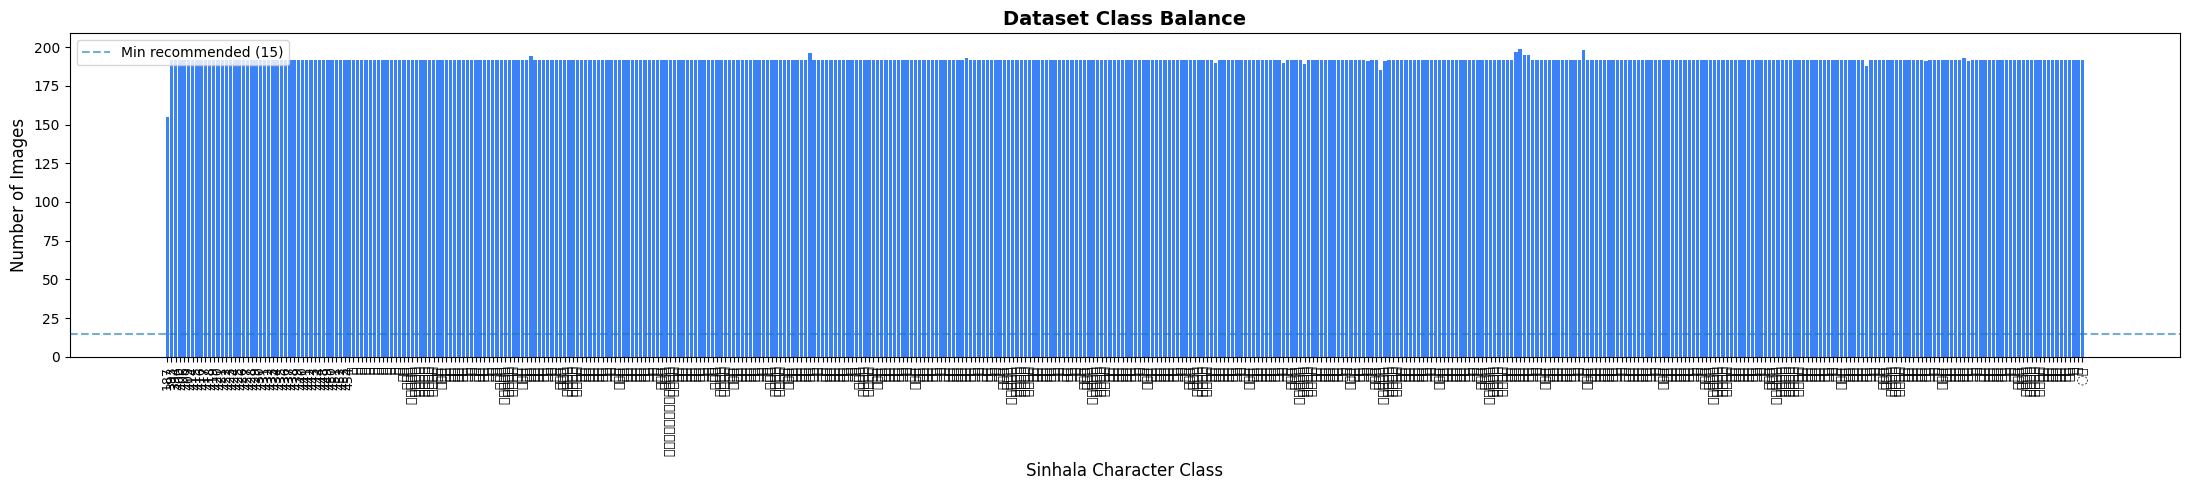

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 5))

letters = list(class_counts.keys())
counts  = list(class_counts.values())
colors  = ['#ef4444' if c < 15 else '#3b82f6' for c in counts]

plt.bar(range(len(letters)), counts, color=colors, width=0.8)
plt.xticks(range(len(letters)), letters, rotation=90, fontsize=9)
plt.ylabel("Number of Images", fontsize=12)
plt.xlabel("Sinhala Character Class", fontsize=12)
plt.title("Dataset Class Balance", fontsize=14, fontweight='bold')

plt.axhline(y=15, linestyle='--', alpha=0.6, label='Min recommended (15)')
plt.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/class_balance.png", dpi=100)
plt.show()